#### GJK - Generalized Difference-Based Collision Detection Algorithm

GJK intersecting case: True | simplex returned: True
GJK separated case   : False

EPA penetration depth: 1.4674397599138471
EPA normal (unit)    : [0.24692577 0.26940445 0.93083237]
MTV (move A by +MTV or B by -MTV): [0.3623487  0.3953348  1.36594043]


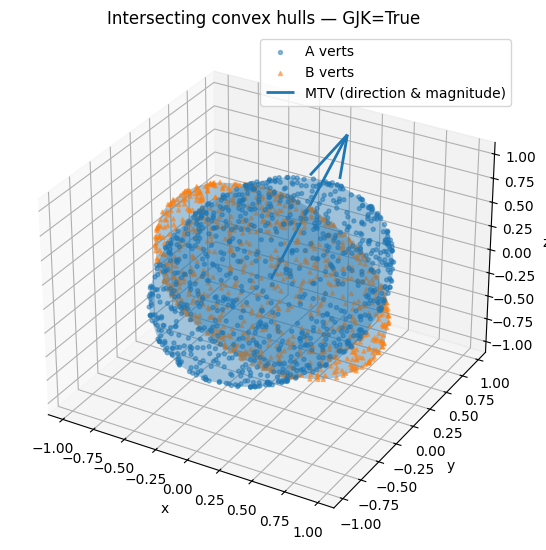

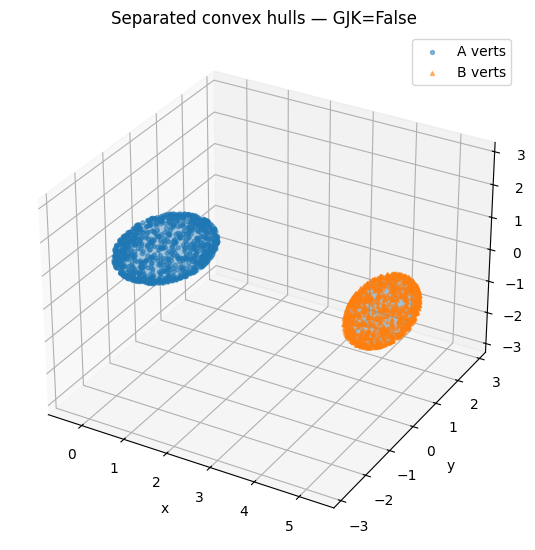

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.spatial import ConvexHull
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

EPS = 1e-9

# ============================================================
# 1) Support mapping (inner-product argmax)
# ============================================================
def support_point(points, d):
    return points[np.argmax(points @ d)]

def support_minkowski(A, B, d):
    return support_point(A, d) - support_point(B, -d)

# ============================================================
# 2) Closest-point routines (Ericson-style) for robust GJK
# ============================================================
def closest_point_segment_to_origin(A, B):
    AB = B - A
    denom = AB @ AB
    if denom < EPS:
        return A, [A]
    t = - (A @ AB) / denom
    t = float(np.clip(t, 0.0, 1.0))
    Q = A + t * AB
    if t <= 1e-12:
        return Q, [A]
    if t >= 1.0 - 1e-12:
        return Q, [B]
    return Q, [A, B]

def closest_point_triangle_to_origin(A, B, C):
    AB = B - A
    AC = C - A
    AP = -A

    d1 = AB @ AP
    d2 = AC @ AP
    if d1 <= 0.0 and d2 <= 0.0:
        return A, [A]

    BP = -B
    d3 = AB @ BP
    d4 = AC @ BP
    if d3 >= 0.0 and d4 <= d3:
        return B, [B]

    vc = d1 * d4 - d3 * d2
    if vc <= 0.0 and d1 >= 0.0 and d3 <= 0.0:
        v = d1 / (d1 - d3)
        Q = A + v * AB
        return Q, [A, B]

    CP = -C
    d5 = AB @ CP
    d6 = AC @ CP
    if d6 >= 0.0 and d5 <= d6:
        return C, [C]

    vb = d5 * d2 - d1 * d6
    if vb <= 0.0 and d2 >= 0.0 and d6 <= 0.0:
        w = d2 / (d2 - d6)
        Q = A + w * AC
        return Q, [A, C]

    va = d3 * d6 - d5 * d4
    if va <= 0.0 and (d4 - d3) >= 0.0 and (d5 - d6) >= 0.0:
        w = (d4 - d3) / ((d4 - d3) + (d5 - d6))
        Q = B + w * (C - B)
        return Q, [B, C]

    denom = 1.0 / (va + vb + vc)
    v = vb * denom
    w = vc * denom
    Q = A + AB * v + AC * w
    return Q, [A, B, C]

def origin_in_tetra(A, B, C, D, tol=1e-12):
    def face_test(P, Q, R, S):
        n = np.cross(Q - P, R - P)
        sign_S = np.dot(n, S - P)
        sign_O = np.dot(n, -P)
        return sign_O * sign_S >= -tol
    return (face_test(A, B, C, D) and
            face_test(A, C, D, B) and
            face_test(A, D, B, C) and
            face_test(B, D, C, A))

def closest_point_tetra_to_origin(A, B, C, D):
    if origin_in_tetra(A, B, C, D):
        return np.zeros(3), [A, B, C, D], True

    faces = [(A,B,C), (A,C,D), (A,D,B), (B,D,C)]
    best_Q = None
    best_subset = None
    best_dist2 = np.inf
    for P,Q,R in faces:
        q, subset = closest_point_triangle_to_origin(P,Q,R)
        dist2 = q @ q
        if dist2 < best_dist2:
            best_dist2 = dist2
            best_Q = q
            best_subset = subset
    return best_Q, best_subset, False

# ============================================================
# 3) Robust GJK that RETURNS a tetra simplex when intersecting
# ============================================================
def gjk_intersect_with_simplex(A, B, max_iter=256):
    A = np.asarray(A, float); B = np.asarray(B, float)

    d = A.mean(axis=0) - B.mean(axis=0)
    if np.linalg.norm(d) < EPS:
        d = np.array([1.0, 0.0, 0.0])

    simplex = [support_minkowski(A, B, d)]
    d = -simplex[0].copy()

    for _ in range(max_iter):
        if np.linalg.norm(d) < 1e-12:
            # Try to grow simplex into a tetra (needed for EPA)
            probes = [
                np.array([1.0, 0.0, 0.0]),
                np.array([0.0, 1.0, 0.0]),
                np.array([0.0, 0.0, 1.0]),
                np.array([1.0, 1.0, 1.0]),
            ]
            for pd in probes:
                a = support_minkowski(A, B, pd)
                if all(np.linalg.norm(a - s) > 1e-9 for s in simplex):
                    simplex.append(a)
                if len(simplex) >= 4:
                    break
            if len(simplex) >= 4 and origin_in_tetra(simplex[0], simplex[1], simplex[2], simplex[3]):
                return True, simplex[:4]
            return True, None

        a = support_minkowski(A, B, d)
        if np.dot(a, d) < 0 + 1e-12:
            return False, None

        simplex.append(a)

        if len(simplex) == 2:
            q, subset = closest_point_segment_to_origin(simplex[0], simplex[1])
            simplex = subset
            d = -q
        elif len(simplex) == 3:
            q, subset = closest_point_triangle_to_origin(simplex[0], simplex[1], simplex[2])
            simplex = subset
            d = -q
        else:
            q, subset, inside = closest_point_tetra_to_origin(simplex[0], simplex[1], simplex[2], simplex[3])
            if inside:
                return True, simplex[:4]
            simplex = subset
            d = -q

        if len(simplex) > 4:
            simplex = simplex[-4:]

    return True, simplex[:4] if len(simplex) >= 4 else None

# ============================================================
# 4) EPA: penetration depth + MTV from Minkowski difference
# ============================================================
def make_face(a, b, c):
    n = np.cross(b - a, c - a)
    ln = np.linalg.norm(n)
    if ln < EPS:
        return None
    n = n / ln
    dist = np.dot(n, a)
    # enforce dist >= 0 (outward)
    if dist < 0:
        n = -n
        dist = -dist
        b, c = c, b
    return {"verts": (a, b, c), "n": n, "dist": dist}

def epa(A, B, simplex4, max_iter=256, tol=1e-6):
    a, b, c, d = simplex4
    faces = []
    for tri in [(a,b,c), (a,c,d), (a,d,b), (b,d,c)]:
        f = make_face(*tri)
        if f is not None:
            faces.append(f)
    if len(faces) < 4:
        raise RuntimeError("EPA init failed (degenerate tetra).")

    for _ in range(max_iter):
        faces.sort(key=lambda f: f["dist"])
        f = faces[0]
        n = f["n"]
        dist = f["dist"]

        p = support_minkowski(A, B, n)
        p_dist = np.dot(n, p)

        if p_dist - dist < tol:
            depth = dist
            mtv = n * depth
            return depth, mtv, n

        # Visible faces from p
        visible = []
        for i, face in enumerate(faces):
            a1, b1, c1 = face["verts"]
            if np.dot(face["n"], p - a1) > 1e-10:
                visible.append(i)

        # Count directed edges from visible faces
        edge_count = {}
        def add_edge(u, v):
            key = (tuple(u), tuple(v))
            edge_count[key] = edge_count.get(key, 0) + 1

        vis_set = set(visible)
        for idx in visible:
            va, vb, vc = faces[idx]["verts"]
            add_edge(va, vb)
            add_edge(vb, vc)
            add_edge(vc, va)

        # Remove visible faces
        faces = [face for i, face in enumerate(faces) if i not in vis_set]

        # Horizon: edges that are not canceled by reverse edge
        horizon = []
        for (u, v), cnt in edge_count.items():
            if cnt != 1:
                continue
            if (v, u) in edge_count:
                continue
            horizon.append((np.array(u), np.array(v)))

        if not horizon:
            depth = dist
            mtv = n * depth
            return depth, mtv, n

        # Stitch new faces from horizon to p
        for u, v in horizon:
            nf = make_face(u, v, p)
            if nf is not None:
                faces.append(nf)

    faces.sort(key=lambda f: f["dist"])
    f = faces[0]
    return f["dist"], f["n"] * f["dist"], f["n"]

# ============================================================
# 5) Random convex polytopes from hull of ellipsoid surface samples
# ============================================================
rng = np.random.default_rng(2026)

def random_rotation(rng):
    M = rng.normal(size=(3, 3))
    Q, _ = np.linalg.qr(M)
    if np.linalg.det(Q) < 0:
        Q[:, 0] *= -1
    return Q

def sample_ellipsoid_surface(center, radii, n, rng):
    center = np.asarray(center, float)
    radii = np.asarray(radii, float)
    R = random_rotation(rng)
    X = rng.normal(size=(n, 3))
    X /= (np.linalg.norm(X, axis=1, keepdims=True) + 1e-12)
    X = X * radii
    X = X @ R.T
    return X + center

def random_polytope_vertices(center, radii, n_raw, rng):
    pts = sample_ellipsoid_surface(center, radii, n_raw, rng)
    hull = ConvexHull(pts)
    return pts[hull.vertices]

# Build two cases
rA = np.array([1.2, 0.9, 0.7])
rB = np.array([1.0, 0.8, 0.6])
n_raw = 900

A_int = random_polytope_vertices([0,0,0], rA, n_raw, rng)
B_int = random_polytope_vertices([0,0,0], rB, n_raw, rng)

A_sep = random_polytope_vertices([0,0,0], rA, n_raw, rng)
B_sep = random_polytope_vertices([5,0,0], rB, n_raw, rng)

# Run GJK + EPA
hit_int, simp_int = gjk_intersect_with_simplex(A_int, B_int)
hit_sep, _ = gjk_intersect_with_simplex(A_sep, B_sep)

print("GJK intersecting case:", hit_int, "| simplex returned:", simp_int is not None)
print("GJK separated case   :", hit_sep)

if hit_int and simp_int is not None:
    depth, mtv, n = epa(A_int, B_int, simp_int, tol=1e-6)
    print("\nEPA penetration depth:", float(depth))
    print("EPA normal (unit)    :", n)
    print("MTV (move A by +MTV or B by -MTV):", mtv)
else:
    depth, mtv, n = None, None, None
    print("\nEPA skipped (no tetra simplex returned).")

# ============================================================
# 6) Visualization: convex hull face patches + optional MTV arrow
# ============================================================
def plot_hull_surfaces(A, B, title, show_mtv=False, mtv=None):
    hullA = ConvexHull(A)
    hullB = ConvexHull(B)

    fig = plt.figure(figsize=(8.0, 6.6))
    ax = fig.add_subplot(111, projection="3d")

    facesA = [A[s] for s in hullA.simplices]
    facesB = [B[s] for s in hullB.simplices]

    polyA = Poly3DCollection(facesA, alpha=0.22)
    polyB = Poly3DCollection(facesB, alpha=0.22)

    ax.add_collection3d(polyA)
    ax.add_collection3d(polyB)

    ax.scatter(A[:,0], A[:,1], A[:,2], s=8, alpha=0.5, marker="o", label="A verts")
    ax.scatter(B[:,0], B[:,1], B[:,2], s=8, alpha=0.5, marker="^", label="B verts")

    if show_mtv and mtv is not None:
        ax.quiver(0,0,0, mtv[0], mtv[1], mtv[2],
                  length=1.0, normalize=False, linewidth=2.0,
                  label="MTV (direction & magnitude)")

    all_pts = np.vstack([A, B])
    mins = all_pts.min(axis=0); maxs = all_pts.max(axis=0)
    ctr = (mins + maxs) / 2
    span = (maxs - mins).max() / 2
    ax.set_xlim(ctr[0]-span, ctr[0]+span)
    ax.set_ylim(ctr[1]-span, ctr[1]+span)
    ax.set_zlim(ctr[2]-span, ctr[2]+span)

    ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z")
    ax.set_title(title)
    ax.legend()
    plt.show()

plot_hull_surfaces(A_int, B_int, f"Intersecting convex hulls — GJK={hit_int}", show_mtv=(mtv is not None), mtv=mtv)
plot_hull_surfaces(A_sep, B_sep, f"Separated convex hulls — GJK={hit_sep}")

#### Convex-Hull Vertex Generation of Tetrahedration of Volume Estimate

Incremental hull:
  faces: 270
  unique hull verts: 137


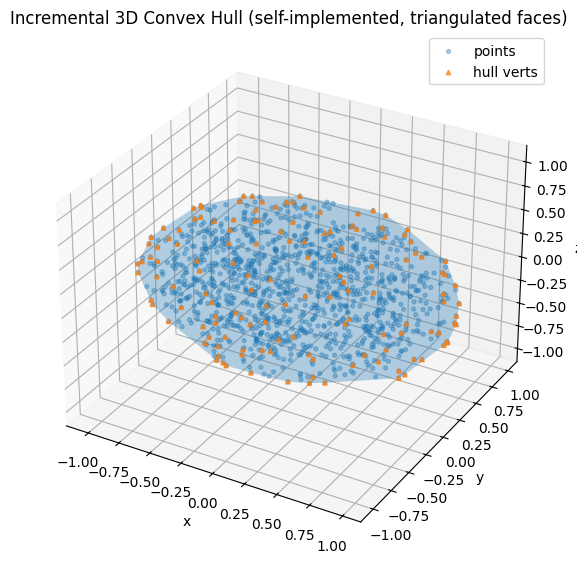

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

EPS = 1e-10

# -----------------------------
# Geometry helpers
# -----------------------------
def norm(v):
    return float(np.linalg.norm(v))

def face_normal(pts, f):
    a, b, c = pts[f[0]], pts[f[1]], pts[f[2]]
    return np.cross(b - a, c - a)

def face_plane(pts, f):
    n = face_normal(pts, f)
    ln = norm(n)
    if ln < EPS:
        return None, None
    n = n / ln
    d = float(n @ pts[f[0]])
    return n, d

def signed_distance_to_face(pts, f, p):
    n, d = face_plane(pts, f)
    if n is None:
        return 0.0
    return float(n @ p - d)

def orient_face_outward(pts, f, inside_point):
    # Ensure inside_point is on the negative (inside) side of plane
    n, d = face_plane(pts, f)
    if n is None:
        return f
    if (n @ inside_point - d) > 0:
        return (f[0], f[2], f[1])
    return f

# -----------------------------
# Initial tetrahedron (non-degenerate)
# -----------------------------
def initial_tetrahedron(pts):
    N = len(pts)
    if N < 4:
        raise ValueError("Need >=4 points.")
    # extremes in x
    i0 = int(np.argmin(pts[:, 0]))
    i1 = int(np.argmax(pts[:, 0]))
    if i0 == i1:
        i1 = int(np.argmax(pts[:, 1]))

    A, B = pts[i0], pts[i1]
    AB = B - A
    ab2 = float(AB @ AB)
    if ab2 < EPS:
        raise ValueError("All points identical.")

    # farthest from line
    P = pts - A
    t = (P @ AB) / ab2
    proj = A + t[:, None] * AB[None, :]
    v = pts - proj
    dist2_line = np.einsum("ij,ij->i", v, v)
    i2 = int(np.argmax(dist2_line))
    if dist2_line[i2] < 1e-12:
        raise ValueError("Points are collinear.")

    # farthest from plane
    A, B, C = pts[i0], pts[i1], pts[i2]
    n = np.cross(B - A, C - A)
    nn = norm(n)
    if nn < EPS:
        raise ValueError("Degenerate plane.")
    n = n / nn
    d = float(n @ A)
    dist_plane = np.abs(pts @ n - d)
    i3 = int(np.argmax(dist_plane))
    if dist_plane[i3] < 1e-12:
        raise ValueError("Points are coplanar.")
    return i0, i1, i2, i3

# -----------------------------
# Incremental 3D Convex Hull
# -----------------------------
def incremental_convex_hull_3d(points, tol=1e-9):
    pts = np.asarray(points, dtype=float)
    N = len(pts)

    i0, i1, i2, i3 = initial_tetrahedron(pts)
    base = [i0, i1, i2, i3]

    # start with tetra faces
    faces = [
        (i0, i1, i2),
        (i0, i3, i1),
        (i0, i2, i3),
        (i1, i3, i2),
    ]
    inside = pts[base].mean(axis=0)
    faces = [orient_face_outward(pts, f, inside) for f in faces]

    # process points (exclude base); sort by distance to centroid for stability
    order = [i for i in range(N) if i not in set(base)]
    c0 = pts.mean(axis=0)
    order.sort(key=lambda i: float(np.linalg.norm(pts[i] - c0)))

    def recompute_inside():
        hv = np.unique(np.array(faces, dtype=int).ravel())
        return pts[hv].mean(axis=0)

    for p_idx in order:
        p = pts[p_idx]

        # outside test: max signed distance over faces
        maxd = max((signed_distance_to_face(pts, f, p) for f in faces), default=0.0)
        if maxd <= tol:
            continue

        # collect visible faces
        visible = [f for f in faces if signed_distance_to_face(pts, f, p) > tol]
        if not visible:
            continue

        vis_set = set(visible)

        # horizon edges: directed edges not canceled by reverse inside visible set
        edge_count = {}
        def add_edge(u, v):
            edge_count[(u, v)] = edge_count.get((u, v), 0) + 1

        for f in visible:
            a, b, c = f
            add_edge(a, b)
            add_edge(b, c)
            add_edge(c, a)

        horizon = []
        for (u, v), cnt in edge_count.items():
            if cnt != 1:
                continue
            if (v, u) in edge_count:
                continue
            horizon.append((u, v))

        # delete visible faces
        faces = [f for f in faces if f not in vis_set]

        # update inside point (for orientation)
        inside = recompute_inside()

        # stitch new faces
        new_faces = []
        for (u, v) in horizon:
            nf = (u, v, p_idx)
            nf = orient_face_outward(pts, nf, inside)
            n, _ = face_plane(pts, nf)
            if n is None:
                continue
            new_faces.append(nf)

        faces.extend(new_faces)

        # occasionally refresh inside (numerical stability)
        if (p_idx % 20) == 0:
            inside = recompute_inside()

    # remove exact duplicates (oriented triangles)
    seen = set()
    uniq = []
    for f in faces:
        if f not in seen:
            seen.add(f)
            uniq.append(f)
    return pts, uniq

# -----------------------------
# Visualization: hull patches + points
# -----------------------------
def plot_hull(pts, faces, title):
    fig = plt.figure(figsize=(8.2, 6.8))
    ax = fig.add_subplot(111, projection="3d")

    tris = [pts[list(f)] for f in faces]
    poly = Poly3DCollection(tris, alpha=0.18)
    ax.add_collection3d(poly)

    ax.scatter(pts[:, 0], pts[:, 1], pts[:, 2], s=8, alpha=0.35, marker="o", label="points")
    hull_verts = np.unique(np.array(faces).ravel())
    ax.scatter(pts[hull_verts, 0], pts[hull_verts, 1], pts[hull_verts, 2],
               s=10, alpha=0.7, marker="^", label="hull verts")

    mins = pts.min(axis=0); maxs = pts.max(axis=0)
    ctr = (mins + maxs) / 2
    span = (maxs - mins).max() / 2
    ax.set_xlim(ctr[0] - span, ctr[0] + span)
    ax.set_ylim(ctr[1] - span, ctr[1] + span)
    ax.set_zlim(ctr[2] - span, ctr[2] + span)

    ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z")
    ax.set_title(title)
    ax.legend()
    plt.show()

# -----------------------------
# Demo run
# -----------------------------
rng = np.random.default_rng(7)
n = 1200
X = rng.normal(size=(n, 3))
X /= (np.linalg.norm(X, axis=1, keepdims=True) + 1e-12)
r = rng.random((n, 1)) ** (1/3)
X = X * r * np.array([1.2, 0.9, 0.7])
X += 0.02 * rng.normal(size=X.shape)

pts, faces = incremental_convex_hull_3d(X, tol=1e-9)
print("Incremental hull:")
print("  faces:", len(faces))
print("  unique hull verts:", len(np.unique(np.array(faces).ravel())))

plot_hull(pts, faces, "Incremental 3D Convex Hull (self-implemented, triangulated faces)")

#### Regularized Canonical Correlation Analysis (RCCA)
Regularized Canonical Correlation Analysis (RCCA) is an extension of Canonical Correlation Analysis (CCA) that incorporates regularization techniques to handle multicollinearity and improve the stability of the canonical correlations. RCCA is particularly useful when dealing with high-dimensional data where the number of variables exceeds the number of observations.
Given data sets (points in $\mathbb{R}^d$) $X$ and $Y$, the Canonical Correlation Analysis explores the correlation between the projections $a^T X$ and $b^T Y$ for $a$ and $b$ vectors in $\mathbb{R}^d$
$$
\rho (X, Y) = \max_{a,b} \text{corr}(a^T X, b^T Y) = \frac{a^T \Sigma_{XY} b}{\sqrt{a^T \Sigma_{XX} a} \sqrt{b^T \Sigma_{YY} b}}
= \frac{\sum_{j=0}^{d-1}\sum_{k=0}^{d-1} a_j b_k \operatorname{Cov}(X_j, Y_k)}
{\sqrt{\sum_{j=0}^{d-1}\sum_{k=0}^{d-1} a_j a_k \operatorname{Cov}(X_j, X_k)} \sqrt{\sum_{j=0}^{d-1}\sum_{k=0}^{d-1} b_j b_k \operatorname{Cov}(Y_j, Y_k)}}
$$
Where $\Sigma_{XX}$ and $\Sigma_{YY}$ are the autocovariance matrix of point set $X$ and $Y$ living in simplex $\mathcal{S} \subset \mathbb{R}^d$

$$
\begin{aligned}
\Sigma_{XX}
= \frac{1}{n-1} X_c^T X_c
&= \bigl[\,\sigma^{(1)}_{ij}\,\bigr]_{i,j=0}^{d-1},
&
\sigma^{(1)}_{ij}
&:= \operatorname{Cov}\!\bigl(x_X^{(i)},\,x_X^{(j)}\bigr),
&
x_X &\sim X,
\\
\Sigma_{YY}
= \frac{1}{n-1} Y_c^T Y_c
&= \bigl[\,\sigma^{(2)}_{ij}\,\bigr]_{i,j=0}^{d-1},
&
\sigma^{(2)}_{ij}
&:= \operatorname{Cov}\!\bigl(x_Y^{(i)},\,x_Y^{(j)}\bigr),
&
x_Y &\sim Y,
\\
\Sigma_{XY}
= \frac{1}{n-1} X_c^T Y_c
&= \bigl[\,\sigma^{(3)}_{ij}\,\bigr]_{i,j=0}^{d-1},
&
\sigma^{(3)}_{ij}
&:= \operatorname{Cov}\!\bigl(x_X^{(i)},\,x_Y^{(j)}\bigr),
&
x_X &\sim X,\; x_Y \sim Y.
\end{aligned}
$$
$$
X_c = X - \bar{X}, \qquad Y_c = Y - \bar{Y}
$$
where each covariance is computed simply by its definition
$$
\begin{aligned}
\operatorname{Cov}(A,B)
&:= \mathbb{E}\!\Bigl[(A-\mathbb{E}[A])\,(B-\mathbb{E}[B])\Bigr],
\\[4pt]
\operatorname{Cov}\!\bigl(x_X^{(i)},x_Y^{(j)}\bigr)
&= \mathbb{E}\!\Bigl[\bigl(x_X^{(i)}-\mathbb{E}[x_X^{(i)}]\bigr)\bigl(x_Y^{(j)}-\mathbb{E}[x_Y^{(j)}]\bigr)\Bigr]
\\
&= \mathbb{E}\!\bigl[x_X^{(i)}x_Y^{(j)}\bigr]
   - \mathbb{E}\!\bigl[x_X^{(i)}\bigr]\;\mathbb{E}\!\bigl[x_Y^{(j)}\bigr],
\\[6pt]
\widehat{\operatorname{Cov}}\!\bigl(x_X^{(i)},x_Y^{(j)}\bigr)
&:= \frac{1}{n-1}\sum_{k=1}^{n}
\bigl(x_{X,k}^{(i)}-\bar{x}_X^{(i)}\bigr)\,
\bigl(x_{Y,k}^{(j)}-\bar{x}_Y^{(j)}\bigr).
\end{aligned}
$$

Observe that
$$
\Sigma_{YX} = \Sigma_{XY}^{\mathsf T},
\quad\text{since}\quad
(\Sigma_{XY})_{ij}=\operatorname{Cov}\!\bigl(x_X^{(i)},x_Y^{(j)}\bigr)
=\operatorname{Cov}\!\bigl(x_Y^{(j)},x_X^{(i)}\bigr)
=(\Sigma_{YX})_{ji}.
$$

We use the standardized Transformation Matrix ($K$) to solve the generalized eigenvalue problem 
$$
\begin{aligned}
\Sigma_{XX}^{-1}\Sigma_{XY}\Sigma_{YY}^{-1}\Sigma_{XY}^{\mathsf T} v = \rho^2 v,\\
\Sigma_{YY}^{-1}\Sigma_{XY}^{\mathsf T}\Sigma_{XX}^{-1}\Sigma_{XY} u = \rho^2 u, \\
K = \widehat{\Sigma_{XX}}^{-1/2}\Sigma_{XY}\widehat{\Sigma_{YY}}^{-1/2} = U S V^{\mathsf T}
\end{aligned}
$$

The approximation of the correlation factor $\rho_{1}$ and cononical weights on the $x$ and $y$ direction $w_X$ and $w_Y$ given by
$$
\rho_{1} = s_{1,1} \in S \to \rho = \max(\text{eig}{K}), \qquad w_X = \widehat{\Sigma_{XX}}^{-1/2} U, \qquad w_Y = \widehat{\Sigma_{YY}}^{-1/2} V
$$
Where $U$ and $V$ are the left and right singular vectors of $K$, and $S$ is the diagonal matrix of singular values. The canonical correlations are given by the singular values in $S$, and the canonical variates are obtained by projecting the original data onto the corresponding singular vectors in $U$ and $V$.
In RCCA, we introduce regularization parameters $\lambda_X$ and $\lambda_Y$ to the covariance matrices to prevent overfitting and improve the stability of the solution. The regularized covariance matrices are defined as follows:
$$
\begin{aligned}
\Sigma_{XX}^{\text{reg}} &= \Sigma_{XX} + \lambda_X I, \\
\Sigma_{YY}^{\text{reg}} &= \Sigma_{YY} + \lambda_Y I,
\end{aligned}
$$

The best approximation for the $k$-ill conditioned matrix $\Sigma_{XX}$, $\Sigma_{XY}$ and $\Sigma_{YY}$
$$
\Sigma_{XY} = 
\Sigma_{XX}^{1/2} K \Sigma_{YY}^{1/2}, \qquad 
\rho = \max\bigr(\text{eig}\bigl((\Sigma_{XX} + \lambda_X I)^{-1/2} \Sigma_{XY} (\Sigma_{YY} + \lambda_Y I)^{-1/2}\bigr)\bigr)
$$

##### Applications in Solve
$$\begin{aligned}
&\text{Use \texttt{sklearn} \texttt{Nyström} or \texttt{RBFSampler} to generate high-dimensional features.}\\
&\text{Apply \texttt{sklearn.cross\_decomposition.CCA} to the expanded features and canonical weights.}
\end{aligned}$$
$$\begin{aligned}
&\textbf{Feature expansion (high-dimensional map)}\\
&\phi:\mathbb{R}^{d_X}\to\mathbb{R}^{D},\qquad \psi:\mathbb{R}^{d_Y}\to\mathbb{R}^{D},\qquad D\gg d_X,d_Y,\\
&Z_X := \phi(X)\in\mathbb{R}^{n\times D},\qquad Z_Y := \psi(Y)\in\mathbb{R}^{n\times D},\\
&\text{where }\phi,\psi\text{ are obtained via} \texttt{sklearn} \texttt{RBFSampler} or \texttt{Nystroem}.\\[6pt]
&\textbf{CCA on expanded features}\\
&\text{Apply }\texttt{sklearn.cross\_decomposition.CCA}\text{ to }(Z_X,Z_Y)\text{ to obtain canonical directions }A,B.\\
&\text{Let }A=[a_1,\dots,a_r]\in\mathbb{R}^{D\times r},\qquad B=[b_1,\dots,b_r]\in\mathbb{R}^{D\times r},\\
&\text{and define canonical variates }U:=Z_XA,\quad V:=Z_YB,\quad
\text{i.e. }u_k = Z_X a_k,\; v_k = Z_Y b_k.\\[6pt]
&\textbf{Canonical weights (as returned by sklearn)}\\
&a_k = \texttt{cca.x\_weights\_}[:,k]\in\mathbb{R}^{D},\qquad
b_k = \texttt{cca.y\_weights\_}[:,k]\in\mathbb{R}^{D}.\\[6pt]
&\textbf{Empirical canonical correlation (component-wise)}\\
&\rho_k \;=\; \operatorname{Corr}(u_k,v_k)
\;=\;\frac{\operatorname{Cov}(u_k,v_k)}{\sqrt{\operatorname{Var}(u_k)\operatorname{Var}(v_k)}}\,,\qquad k=1,\dots,r.
\end{aligned}$$

In [3]:
# KaTeX notes (for your write-up):
#   Feature expansion:  φ(x) ∈ R^D,  ψ(y) ∈ R^D
#   CCA solves (in population form):
#     max_{a,b} Corr(a^T φ(X), b^T ψ(Y))
#   sklearn returns canonical "weights" a_k, b_k as cca.x_weights_[:,k], cca.y_weights_[:,k]

import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.kernel_approximation import RBFSampler, Nystroem
from sklearn.cross_decomposition import CCA
from sklearn.model_selection import train_test_split

def fit_kernel_cca(
    X, Y,
    *,
    method="rbf",          # "rbf" (RBFSampler) or "nystroem"
    D=2048,                # expanded feature dimension
    gamma=1.0,             # RBF kernel parameter
    n_components=10,       # number of canonical components
    random_state=0,
    test_size=0.2
):
    """
    Kernel-approx CCA:
      1) standardize X,Y
      2) approximate RBF feature maps via RBFSampler or Nystroem
      3) standardize expanded features (important)
      4) run linear CCA on expanded features
    Returns a dict with fitted objects + canonical correlations.
    """

    X = np.asarray(X, dtype=float)
    Y = np.asarray(Y, dtype=float)
    assert X.shape[0] == Y.shape[0], "X and Y must have same number of samples"

    Xtr, Xte, Ytr, Yte = train_test_split(
        X, Y, test_size=test_size, random_state=random_state
    )

    # ----- pick feature map -----
    if method.lower() == "rbf":
        phi = RBFSampler(gamma=gamma, n_components=D, random_state=random_state)
        psi = RBFSampler(gamma=gamma, n_components=D, random_state=random_state)
    elif method.lower() == "nystroem":
        # For Nystroem, n_components is #landmarks => output dim
        phi = Nystroem(kernel="rbf", gamma=gamma, n_components=D, random_state=random_state)
        psi = Nystroem(kernel="rbf", gamma=gamma, n_components=D, random_state=random_state)
    else:
        raise ValueError("method must be 'rbf' or 'nystroem'")

    # ----- build pipelines for each view -----
    # Standardize raw → expand → standardize expanded (often helps CCA numerics)
    Xpipe = Pipeline([
        ("scaler_raw", StandardScaler(with_mean=True, with_std=True)),
        ("feat", phi),
        ("scaler_feat", StandardScaler(with_mean=True, with_std=True)),
    ])
    Ypipe = Pipeline([
        ("scaler_raw", StandardScaler(with_mean=True, with_std=True)),
        ("feat", psi),
        ("scaler_feat", StandardScaler(with_mean=True, with_std=True)),
    ])

    Zx_tr = Xpipe.fit_transform(Xtr)   # φ(X)
    Zy_tr = Ypipe.fit_transform(Ytr)   # ψ(Y)
    Zx_te = Xpipe.transform(Xte)
    Zy_te = Ypipe.transform(Yte)

    # ----- CCA on expanded features -----
    cca = CCA(n_components=n_components, max_iter=2000, tol=1e-8, scale=False)
    U_tr, V_tr = cca.fit_transform(Zx_tr, Zy_tr)   # canonical variates
    U_te, V_te = cca.transform(Zx_te, Zy_te)

    # Canonical correlations (empirical): corr(U_k, V_k)
    def col_corr(A, B):
        out = []
        for k in range(min(A.shape[1], B.shape[1])):
            a = A[:, k]
            b = B[:, k]
            # guard against tiny numerical issues
            denom = (np.std(a) * np.std(b))
            out.append(np.corrcoef(a, b)[0, 1] if denom > 0 else np.nan)
        return np.array(out)

    corr_tr = col_corr(U_tr, V_tr)
    corr_te = col_corr(U_te, V_te)

    # Canonical "weights" in expanded-feature coordinates:
    #   a_k = cca.x_weights_[:,k], b_k = cca.y_weights_[:,k]
    A = cca.x_weights_   # shape (D, n_components)
    B = cca.y_weights_   # shape (D, n_components)

    return {
        "Xpipe": Xpipe,
        "Ypipe": Ypipe,
        "cca": cca,
        "A": A,                 # canonical weights for φ(X)
        "B": B,                 # canonical weights for ψ(Y)
        "U_tr": U_tr,
        "V_tr": V_tr,
        "U_te": U_te,
        "V_te": V_te,
        "corr_tr": corr_tr,
        "corr_te": corr_te,
    }


# ----------------------------
# Example usage
# ----------------------------
if __name__ == "__main__":
    rng = np.random.default_rng(0)
    n = 800
    dx, dy = 5, 6

    # Synthetic paired data with some shared latent structure
    Z = rng.normal(size=(n, 2))
    X = Z @ rng.normal(size=(2, dx)) + 0.3 * rng.normal(size=(n, dx))
    Y = Z @ rng.normal(size=(2, dy)) + 0.3 * rng.normal(size=(n, dy))

    res = fit_kernel_cca(
        X, Y,
        method="rbf",   # or "nystroem"
        D=2048,
        gamma=0.7,
        n_components=5,
        random_state=0
    )

    print("Train canonical correlations:", np.round(res["corr_tr"], 4))
    print("Test  canonical correlations:", np.round(res["corr_te"], 4))
    print("A shape (φ(X) weights):", res["A"].shape)
    print("B shape (ψ(Y) weights):", res["B"].shape)

Train canonical correlations: [1. 1. 1. 1. 1.]
Test  canonical correlations: [ 0.0676  0.026   0.0477 -0.0223 -0.0281]
A shape (φ(X) weights): (2048, 5)
B shape (ψ(Y) weights): (2048, 5)


In [4]:
"""
Goal:
  1) Use sklearn Nyström or RBFSampler to generate high-dimensional features.
  2) Apply sklearn.cross_decomposition.CCA on the expanded features.
  3) Read off canonical weights (in expanded-feature coordinates).

KaTeX-friendly notes for write-up:
  Z_X = φ(X) ∈ R^{n×D},   Z_Y = ψ(Y) ∈ R^{n×D}
  CCA returns weights A,B so that:
    u_k = Z_X a_k,  v_k = Z_Y b_k
  where a_k = cca.x_weights_[:,k], b_k = cca.y_weights_[:,k].
"""

import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.kernel_approximation import RBFSampler, Nystroem
from sklearn.cross_decomposition import CCA


def expand_features(X, *, method="rbf", D=2048, gamma=1.0, random_state=0):
    """
    Expand input features with either:
      - RBFSampler (random Fourier features)
      - Nystroem   (Nyström approximation)

    Returns: (Z, fitted_pipeline)
      Z has shape (n_samples, D)
    """
    X = np.asarray(X, dtype=float)

    if method.lower() == "rbf":
        featurizer = RBFSampler(gamma=gamma, n_components=D, random_state=random_state)
    elif method.lower() == "nystroem":
        featurizer = Nystroem(kernel="rbf", gamma=gamma, n_components=D, random_state=random_state)
    else:
        raise ValueError("method must be 'rbf' or 'nystroem'")

    pipe = Pipeline([
        ("scale_raw", StandardScaler(with_mean=True, with_std=True)),
        ("feat", featurizer),
        ("scale_feat", StandardScaler(with_mean=True, with_std=True)),
    ])

    Z = pipe.fit_transform(X)
    return Z, pipe


def cca_on_expanded_features(
    X, Y,
    *,
    method="rbf",
    D=2048,
    gamma=1.0,
    n_components=10,
    random_state=0
):
    """
    Kernel-approx CCA:
      Zx = φ(X), Zy = ψ(Y) via RBFSampler or Nystroem
      then run linear CCA on (Zx, Zy)

    Returns a dict containing:
      - canonical variates U,V
      - canonical weights A,B (expanded-feature coordinates)
      - fitted feature pipelines + CCA model
    """
    Zx, Xpipe = expand_features(X, method=method, D=D, gamma=gamma, random_state=random_state)
    Zy, Ypipe = expand_features(Y, method=method, D=D, gamma=gamma, random_state=random_state)

    cca = CCA(n_components=n_components, max_iter=2000, tol=1e-8, scale=False)
    U, V = cca.fit_transform(Zx, Zy)

    # Canonical weights in expanded-feature coordinates:
    #   A[:,k] corresponds to a_k for φ(X); B[:,k] corresponds to b_k for ψ(Y).
    A = cca.x_weights_  # shape (D, n_components)
    B = cca.y_weights_  # shape (D, n_components)

    # Empirical canonical correlations corr(U_k, V_k)
    corrs = np.array([np.corrcoef(U[:, k], V[:, k])[0, 1] for k in range(U.shape[1])])

    return {
        "Zx": Zx, "Zy": Zy,
        "Xpipe": Xpipe, "Ypipe": Ypipe,
        "cca": cca,
        "U": U, "V": V,
        "A": A, "B": B,
        "corrs": corrs,
    }


# ----------------------------
# Minimal example
# ----------------------------
if __name__ == "__main__":
    rng = np.random.default_rng(0)
    n = 600
    dx, dy = 5, 7

    # synthetic paired data with shared latent structure
    latent = rng.normal(size=(n, 2))
    X = latent @ rng.normal(size=(2, dx)) + 0.4 * rng.normal(size=(n, dx))
    Y = latent @ rng.normal(size=(2, dy)) + 0.4 * rng.normal(size=(n, dy))

    res = cca_on_expanded_features(
        X, Y,
        method="rbf",      # "rbf" or "nystroem"
        D=2048,
        gamma=0.8,
        n_components=5,
        random_state=0
    )

    print("Expanded shapes:", res["Zx"].shape, res["Zy"].shape)
    print("Canonical correlations:", np.round(res["corrs"], 4))
    print("Canonical weights A (for φ(X)):", res["A"].shape)
    print("Canonical weights B (for ψ(Y)):", res["B"].shape)

Expanded shapes: (600, 2048) (600, 2048)
Canonical correlations: [1. 1. 1. 1. 1.]
Canonical weights A (for φ(X)): (2048, 5)
Canonical weights B (for ψ(Y)): (2048, 5)


In [ ]:
import numpy as np

def hull_unique_vertices(points, tol=1e-9):
    pts, faces = incremental_convex_hull_3d(points, tol=tol)
    hv = np.unique(np.asarray(faces, dtype=int).ravel())
    return pts[hv]  # (m,3)

def center_scale(P, eps=1e-12):
    P = np.asarray(P, float)
    P = P - P.mean(axis=0, keepdims=True)
    s = np.sqrt((P * P).sum(axis=1).mean())
    return P / (s + eps)

def nn_match(A, B):
    """
    Return paired coordinates by nearest-neighbor matching A -> B.
    Output: two arrays of shape (len(A), 3) with correspondences.
    """
    # brute-force NN (OK for hull sizes ~ few thousands); replace with KDTree if needed
    # D[i,j] = ||A_i - B_j||^2
    D2 = ((A[:, None, :] - B[None, :, :]) ** 2).sum(axis=2)
    j = np.argmin(D2, axis=1)
    return A, B[j]

def pearson_corr_flat(U, V, eps=1e-12):
    u = U.reshape(-1)
    v = V.reshape(-1)
    u = u - u.mean()
    v = v - v.mean()
    denom = (np.linalg.norm(u) * np.linalg.norm(v)) + eps
    return float((u @ v) / denom)

def hull_vertex_correlation_scalar(X, Y, tol=1e-9):
    """
    One-number correlation between the *unique convex-hull vertices* of X and Y.
    Symmetric: average of A->B and B->A NN matches.
    """
    HX = center_scale(hull_unique_vertices(X, tol=tol))
    HY = center_scale(hull_unique_vertices(Y, tol=tol))

    Ax, By = nn_match(HX, HY)   # X-hull matched into Y-hull
    Ay, Bx = nn_match(HY, HX)   # Y-hull matched into X-hull

    rho1 = pearson_corr_flat(Ax, By)
    rho2 = pearson_corr_flat(Bx, Ay)  # note swapped naming for symmetry
    return 0.5 * (rho1 + rho2)

In [11]:
# Generate X_points and Y_points (3D point clouds), then compute
# the convex-hull-vertex correlation scalar.

import numpy as np

# -----------------------------
# Synthetic point clouds
# -----------------------------
rng = np.random.default_rng(7)
n = 2000

# X_points: noisy ellipsoid-ish cloud (non-spherical)
X_points = rng.normal(size=(n, 3))
X_points /= (np.linalg.norm(X_points, axis=1, keepdims=True) + 1e-12)
r = rng.random((n, 1)) ** (1/3)          # uniform in volume
X_points = X_points * r * np.array([1.2, 0.9, 0.7])
X_points += 0.02 * rng.normal(size=X_points.shape)

# Y_points: related cloud (affine + mild warp + noise)
A = np.array([[1.00, 0.15, 0.05],
              [-0.10, 0.95, 0.08],
              [0.02, -0.06, 1.05]], dtype=float)
Y_points = X_points @ A.T
Y_points += 0.03 * np.sin(6.0 * Y_points[:, [0]]) * np.array([0.0, 1.0, 0.5])  # small nonlinearity
Y_points += 0.02 * rng.normal(size=Y_points.shape)

# -----------------------------
# Now compute your scalar
# -----------------------------
rho = hull_vertex_correlation_scalar(X_points, Y_points, tol=1e-9)
print("Hull-vertex correlation (scalar):", rho)

Hull-vertex correlation (scalar): 0.990791913152268


In [9]:
# Ensure X_points and Y_points are *ONLY* the unique convex-hull vertices (no faces used downstream).

import numpy as np

# ------------------------------------------------------------
# 1) Generate two 3D point clouds (dense), then reduce to hull verts only
# ------------------------------------------------------------
rng = np.random.default_rng(7)
n = 2000

# Dense cloud X (ellipsoid-ish, noisy)
X_dense = rng.normal(size=(n, 3))
X_dense /= (np.linalg.norm(X_dense, axis=1, keepdims=True) + 1e-12)
r = rng.random((n, 1)) ** (1/3)
X_dense = X_dense * r * np.array([1.2, 0.9, 0.7])
X_dense += 0.02 * rng.normal(size=X_dense.shape)

# Dense cloud Y (related but not identical)
A = np.array([[1.00, 0.15, 0.05],
              [-0.10, 0.95, 0.08],
              [0.02, -0.06, 1.05]], dtype=float)
Y_dense = X_dense @ A.T
Y_dense += 0.03 * np.sin(6.0 * Y_dense[:, [0]]) * np.array([0.0, 1.0, 0.5])
Y_dense += 0.02 * rng.normal(size=Y_dense.shape)

# ------------------------------------------------------------
# 2) Convert to UNIQUE hull vertices ONLY
#    (this uses faces internally just to *find* hull vertices, then discards faces)
# ------------------------------------------------------------
def unique_hull_vertices_only(points, tol=1e-9):
    pts, faces = incremental_convex_hull_3d(points, tol=tol)
    hv = np.unique(np.asarray(faces, dtype=int).ravel())
    return pts[hv]

X_points = unique_hull_vertices_only(X_dense, tol=1e-9)
Y_points = unique_hull_vertices_only(Y_dense, tol=1e-9)

print("X: unique hull verts =", len(X_points))
print("Y: unique hull verts =", len(Y_points))

# ------------------------------------------------------------
# 3) Correlate hull-vertex sets into ONE scalar
# ------------------------------------------------------------
rho = hull_vertex_correlation_scalar(X_points, Y_points, tol=1e-9)
print("Hull-vertex correlation (scalar):", rho)

X: unique hull verts = 168
Y: unique hull verts = 139
Hull-vertex correlation (scalar): 0.990791913152268


In [12]:
# Example:
X_points = hull_unique_vertices(X_points, tol=1e-9)
Y_points = hull_unique_vertices(Y_points, tol=1e-9)
rho = hull_vertex_correlation_scalar(X_points, Y_points, tol=1e-9)
print("Hull-vertex correlation (scalar):", rho)
rho = hull_vertex_correlation_scalar(X_points, Y_points, tol=1e-9)
print("Hull-vertex correlation (scalar):", rho)

Hull-vertex correlation (scalar): 0.990791913152268
Hull-vertex correlation (scalar): 0.990791913152268


#### Green-Gauss Method for Gradient Calculation in 3D CFD
For a cell $P$ with volume $V_P$, the average gradient $(\nabla T)_P$ is calculated by summing all surrounding faces $f$
$$
(\nabla T)_P = \frac{1}{V_P} \sum_{f \in \text{faces}(P)} T_f \mathbf{S}_f = 
\frac{1}{V_P} \sum_{f \in \text{faces}(P)} \left( \frac{T_P + T_{N_f}}{2} \right) \vec{n}_{f} A_f = \biggl(\frac{\partial T}{\partial x}, \frac{\partial T}{\partial y}, \frac{\partial T}{\partial z}\biggr)
$$
Cell-to-Face Linear Interpolation
$$
T_f = w_P T_P + w_{N_f} T_{N_f}, \qquad w_P = w_{N_f} = 0.5
$$
Nodal averaging
$$
T_f = \frac{1}{M}
\sum_{i=1}^M T_{\text{node}, i}, \qquad M = \text{number of nodes on face }
$$
With Quadrature of Minimal Loss
$$
T_f = \sum_{i=1}^M w_i T_{\text{node}, i}, \qquad \sum_{i=1}^M w_i = 1, \qquad \int_{f} T \mathbb{d} \vec{S}
\approx T_f \vec{S}_f =
\sum_{i=1}^M w_i T_{\text{node}, i} A_f
$$

##### S-Function Approximations
For non-orthogonal grids, we expand the $T_f$ calculation by incorporating the projection distance-weighted interpolation to better handle the skewness of the cells
$$
T_f = \frac{d_{fN}T_P + d_{fP}T_N}{d_{fN} + d_{fP}}
$$
where $d_{fP}$ is the distance from the face centroid to cell center $P$
The Discrete Form of the S-Function is given by
$$
\begin{aligned}
[\nabla T]_p^{(k)} \approx \frac{1}{V_p} \sum_{f=1}^{N_f} \biggl(\mathscr{F}\{T_p^{(k)}, T_N^{(k)}\}\cdot \vec{n}_f A_f\biggr), \qquad \text{the geometric forms } \bigl(\frac{\vec{n}_f A_f}{V_p}\bigr) \text{stored in the 
```python
DWork mdlStart
```
} 
\end{aligned}
$$
The Covariance Update from Recursive Approximation
$$
\Sigma_{XX}^{(k)} = (1 - \alpha)\Sigma_{XX}^{(k-1)} + \alpha(X_c^{(k)}X_c^{(k)T})
$$
The Standard Projection Form

The S-function outputs the projected "Canonical Scores" $u$ and $v$ using the split matrices
$$
\begin{aligned}
u^{(k)} = [\Sigma_{XX}^{(k)} + \lambda_{X} I]^{-1/2} \cdot X_c^{(k)}\\
v^{(k)} = [\Sigma_{YY}^{(k)} + \lambda_{Y} I]^{-1/2} \cdot Y_c^{(k)}
\end{aligned}
$$
The Correlation Update
$$
\rho^{(k)} = \frac{u^{(k)T} \Sigma
_{XY}^{(k)} v^{(k)}}{\sqrt{u^{(k)T} \Sigma_{XX}^{(k)} u^{(k)}} \sqrt{v^{(k)T} \Sigma_{YY}^{(k)} v^{(k)}}}
$$
The Eigenvalue Split
$$
S = A^{1/2}A^{-1/2} =
(V \Lambda^{1/2} V^{\mathsf T})
(V \Lambda^{-1/2} V^{\mathsf T}) =
V \Lambda^{1/2} V^{\mathsf T} V \Lambda^{-1/2} V^{\mathsf T} = I
$$
On real CFD data, $\Sigma$ can be ill-conditioned; even if you refuse “regularization,” you still need a numerical floor for $s_i$ (otherwise division by zero is inevitable). A minimal “non-regularized but finite” practice is:
$s_i^{-1/2} \leftarrow \frac{1}{\sqrt{\max(s_i,\varepsilon)}}\quad\text{with tiny }\varepsilon$.

In [5]:
def greenGauss3D(T_neighbors, face_normals, face_areas, cell_volume, 
                 T_p=None, weights=None, method='direct'):
    """
    Computes the gradient of a scalar T using the Green-Gauss theorem.
    
    Parameters:
    -----------
    T_neighbors  : array_like, shape (N,)
                   Scalar values (T_N) at neighboring cell centers or nodes.
    face_normals : array_like, shape (N, 3)
                   Outward unit normal vectors [nx, ny, nz] for each face.
    face_areas   : array_like, shape (N,)
                   Surface areas of each face.
    cell_volume  : float
                   Volume of the owner cell (Vp).
    T_p          : float, optional
                   Value at the owner cell center. Required for 'linear' interpolation.
    weights      : array_like, shape (N,), optional
                   Interpolation weights (0.5 for simple average).
    method       : str, 'direct', 'linear', or 'nodal'
    """
    
    # Convert inputs to numpy arrays for vector math
    T_N = np.array(T_neighbors)
    n_f = np.array(face_normals)
    A_f = np.array(face_areas)
    
    # 1. Determine Face Values (Tf) based on the chosen method
    if method == 'linear':
        # Tf = w*Tp + (1-w)*TN. Default weight is 0.5 (arithmetic mean)
        if T_p is None:
            raise ValueError("T_p is required for linear interpolation.")
        w = np.array(weights) if weights is not None else 0.5
        T_f = w * T_p + (1 - w) * T_N
        
    elif method == 'nodal':
        # Tf = average of nodes forming the face. 
        # Here we assume T_neighbors contains the pre-averaged nodal values for each face.
        T_f = T_N
        
    else: # 'direct' - assumes T_neighbors are already the values at the face centroids
        T_f = T_N

    # 2. Compute Surface Integral: sum(Tf * nf * Af)
    # Using element-wise multiplication and broadcasting
    # T_f[:, np.newaxis] turns (N,) into (N, 1) to multiply against (N, 3)
    surface_integrals = T_f[:, np.newaxis] * n_f * A_f[:, np.newaxis]
    
    # 3. Sum contributions and normalize by volume
    grad_sum = np.sum(surface_integrals, axis=0)
    gradT = grad_sum / cell_volume
    
    return gradT

# --- Example Usage ---
# Hexahedral cell in a gradient field dT/dx = 10
cell_val = 300.0
neigh_vals = np.array([310, 290, 300, 300, 300, 300]) # X+, X-, Y+, Y-, Z+, Z-
normals = np.array([[1,0,0], [-1,0,0], [0,1,0], [0,-1,0], [0,0,1], [0,0,-1]])
areas = np.full(6, 0.01) # 0.1 x 0.1 faces
vol = 0.001              # 0.1^3 cube

grad = greenGauss3D(neigh_vals, normals, areas, vol, T_p=cell_val, method='linear')
print(f"Gradient Vector: {grad}")


Gradient Vector: [100.   0.   0.]


In [8]:
import numpy as np

EPS = 1e-12

# ============================================================
# 0) Mesh container for non-orthogonal, non-regular FV grids
# ============================================================

class FVMesh:
    """
    Minimal unstructured FV mesh representation for Green–Gauss in 3D.

    Required:
      cell_centers: (Nc,3)
      cell_volumes: (Nc,)
      face_centers: (Nf,3)
      face_area_vec: (Nf,3)   # oriented outward from owner cell
      owner: (Nf,) int
      neigh: (Nf,) int        # -1 for boundary faces
    Optional:
      btype: (Nf,) int or str  # boundary type tag per face if neigh==-1
      bvalue: (Nf,) float      # Dirichlet value per boundary face (if used)

    Notes:
      - face_area_vec must be consistent: outward from owner cell.
      - boundary closure is handled in Green–Gauss routine.
    """
    def __init__(self,
                 cell_centers, cell_volumes,
                 face_centers, face_area_vec,
                 owner, neigh,
                 btype=None, bvalue=None):
        self.Cc = np.asarray(cell_centers, float)
        self.V = np.asarray(cell_volumes, float)
        self.Cf = np.asarray(face_centers, float)
        self.Sf = np.asarray(face_area_vec, float)
        self.owner = np.asarray(owner, int)
        self.neigh = np.asarray(neigh, int)

        self.Nc = self.Cc.shape[0]
        self.Nf = self.Sf.shape[0]

        if btype is None:
            self.btype = np.zeros(self.Nf, dtype=int)  # 0 => default Dirichlet if boundary and bvalue provided
        else:
            self.btype = np.asarray(btype)

        if bvalue is None:
            self.bvalue = np.zeros(self.Nf, dtype=float)
        else:
            self.bvalue = np.asarray(bvalue, float)


# ============================================================
# 1) Geometry precompute: non-orthogonal distance weights
# ============================================================

def precompute_face_distances(mesh: FVMesh, use_normal_projection=True, eps=EPS):
    """
    Precompute d_fP and d_fN for each face.
      d_fP: distance from face centroid to owner cell center
      d_fN: distance from face centroid to neighbor cell center (0 for boundary)
    For non-orthogonal grids, a robust choice is projection along unit normal.

    Returns:
      dfP: (Nf,)
      dfN: (Nf,)
      n_hat: (Nf,3) unit normals (from Sf)
      Af: (Nf,) face areas
    """
    Sf = mesh.Sf
    Af = np.linalg.norm(Sf, axis=1)
    n_hat = Sf / (Af[:, None] + eps)

    P = mesh.owner
    N = mesh.neigh

    rP = mesh.Cf - mesh.Cc[P]  # (Nf,3)
    if use_normal_projection:
        dfP = np.abs(np.einsum("ij,ij->i", rP, n_hat))
    else:
        dfP = np.linalg.norm(rP, axis=1)

    dfN = np.zeros(mesh.Nf, dtype=float)
    interior = (N >= 0)
    if np.any(interior):
        rN = mesh.Cc[N[interior]] - mesh.Cf[interior]
        if use_normal_projection:
            dfN[interior] = np.abs(np.einsum("ij,ij->i", rN, n_hat[interior]))
        else:
            dfN[interior] = np.linalg.norm(rN, axis=1)

    return dfP, dfN, n_hat, Af


# ============================================================
# 2) Green–Gauss gradient on non-orthogonal grids
#    with S-function face interpolation
# ============================================================

def green_gauss_grad_T(mesh: FVMesh, T_cell,
                       dfP, dfN,
                       boundary_mode="dirichlet",
                       use_nodal_averaging=False,
                       face_nodes=None,
                       T_node=None,
                       face_quad_weights=None,
                       eps=EPS):
    """
    Compute per-cell Green–Gauss gradient using:
      (∇T)_P = (1/V_P) Σ_{faces f of P} T_f S_{f->P}

    Face interpolation ("S-function"):
      For interior faces:
        T_f = (d_fN T_P + d_fP T_N) / (d_fN + d_fP)

      For boundary faces:
        - dirichlet: T_f = bvalue[f] (or fallback to T_P if no bvalue given)
        - neumann:   T_f = T_P + (∇T · (Cf-Cp))  [requires gradient; not implemented here]
                    (placeholder; raise)

    If you want nodal averaging / quadrature:
      Provide:
        face_nodes: list of arrays, length Nf, each array has node indices on that face
        T_node: (Nnodes,) nodal values
        face_quad_weights: list of arrays of weights matching face_nodes[f] length
      Then boundary/interior face value uses nodal quadrature:
        T_f = Σ_i w_i T_node[node_i]
      This overrides the cell-based interpolation if use_nodal_averaging=True.

    Returns:
      grad: (Nc,3)
    """
    T = np.asarray(T_cell, float)
    Nc, Nf = mesh.Nc, mesh.Nf

    g = np.zeros((Nc, 3), dtype=float)

    P = mesh.owner
    N = mesh.neigh
    Sf = mesh.Sf

    interior = (N >= 0)
    boundary = ~interior

    # ----- Face values Tf -----
    Tf = np.zeros(Nf, dtype=float)

    if use_nodal_averaging:
        if face_nodes is None or T_node is None:
            raise ValueError("use_nodal_averaging=True requires face_nodes and T_node.")
        if face_quad_weights is None:
            # simple average
            for f in range(Nf):
                nodes = face_nodes[f]
                Tf[f] = float(np.mean(T_node[nodes]))
        else:
            for f in range(Nf):
                nodes = face_nodes[f]
                w = face_quad_weights[f]
                Tf[f] = float(np.dot(w, T_node[nodes]))
    else:
        # interior: projection distance-weighted interpolation
        if np.any(interior):
            denom = (dfN[interior] + dfP[interior]) + eps
            Tf[interior] = (dfN[interior] * T[P[interior]] + dfP[interior] * T[N[interior]]) / denom

        # boundary closure
        if np.any(boundary):
            if boundary_mode.lower() == "dirichlet":
                # if bvalue not set, fallback to owner cell value
                Tf[boundary] = mesh.bvalue[boundary]
                # if bvalue all zeros but you didn't mean it, you can switch to fallback here:
                # Tf[boundary] = np.where(mesh.bvalue[boundary] != 0.0, mesh.bvalue[boundary], T[P[boundary]])
                # safer fallback (avoid accidental zeros):
                # Tf[boundary] = T[P[boundary]] if you want pure extrapolation
            elif boundary_mode.lower() == "neumann":
                raise NotImplementedError("Neumann boundary requires a separate reconstruction; not implemented.")
            else:
                raise ValueError("boundary_mode must be 'dirichlet' or 'neumann'.")

    # ----- Scatter accumulate (Sf outward from owner) -----
    # owner contribution: + Tf * Sf
    np.add.at(g, P, Tf[:, None] * Sf)

    # neighbor contribution (interior only): - Tf * Sf
    if np.any(interior):
        np.add.at(g, N[interior], -Tf[interior, None] * Sf[interior])

    # divide by volume
    g *= (1.0 / (mesh.V[:, None] + eps))
    return g


# ============================================================
# 3) Recursive covariance update (non-regularized)
# ============================================================

def center_features(X, mean=None):
    """
    Center features:
      X: (n,d)
    Returns:
      Xc, mean
    """
    X = np.asarray(X, float)
    if mean is None:
        mean = X.mean(axis=0, keepdims=True)
    else:
        mean = np.asarray(mean, float).reshape(1, -1)
    return X - mean, mean

def rec_cov_update(S_prev, Xc, alpha):
    """
    Σ^{(k)} = (1-α) Σ^{(k-1)} + α (Xc^T Xc)
    where Xc is (n,d) and Xc^T Xc is (d,d).
    """
    Xc = np.asarray(Xc, float)
    S_new = (1.0 - alpha) * S_prev + alpha * (Xc.T @ Xc)
    return S_new

def inv_sqrtm_sym(S, eps=EPS):
    """
    Symmetric inverse square-root using eigendecomposition:
      S = Q diag(s) Q^T
      S^{-1/2} = Q diag(1/sqrt(max(s,eps))) Q^T
    """
    S = np.asarray(S, float)
    S = 0.5 * (S + S.T)  # enforce symmetry
    w, Q = np.linalg.eigh(S)
    inv_sqrt = 1.0 / np.sqrt(np.maximum(w, eps))
    return (Q * inv_sqrt[None, :]) @ Q.T

def canonical_scores_nonregularized(Xc, Yc, Sxx, Syy, eps=EPS):
    """
    Non-regularized canonical score projection:
      u = Σxx^{-1/2} Xc^T   (if Xc is (n,dx), u is (dx,n) or transpose style)
    Here we return per-sample scores:
      U = Xc Σxx^{-1/2}   -> (n,dx)
      V = Yc Σyy^{-1/2}   -> (n,dy)
    """
    Wx = inv_sqrtm_sym(Sxx, eps=eps)  # (dx,dx)
    Wy = inv_sqrtm_sym(Syy, eps=eps)  # (dy,dy)
    U = Xc @ Wx
    V = Yc @ Wy
    return U, V, Wx, Wy


# ============================================================
# 4) "One-step" pipeline: CFD gradient -> features -> RCCA pieces
#    (non-regularized scores only; no eigen solve for rho)
# ============================================================

def step_sfunction_cfd_cca(mesh: FVMesh,
                           T_cell,
                           dfP, dfN,
                           *,
                           alpha=0.05,
                           state=None,
                           feature_mode="gradT",
                           boundary_mode="dirichlet",
                           eps=EPS):
    """
    One timestep:
      - compute gradT using Green–Gauss on non-orthogonal grid
      - build features X (and Y optionally)
      - update recursive covariances Σxx, Σyy, Σxy (if Y provided)
      - output non-regularized canonical scores U,V (whitened features)

    Inputs:
      T_cell: (Nc,)
      feature_mode:
        - "gradT" => X := per-cell gradient (Nc,3)
      state: dict containing previous covariances & means; if None, initializes.

    Returns:
      out: dict with gradients, centered features, updated covariances, scores, and updated state
    """
    # 1) CFD gradient
    gradT = green_gauss_grad_T(mesh, T_cell, dfP, dfN, boundary_mode=boundary_mode, eps=eps)

    # 2) Features
    if feature_mode == "gradT":
        X = gradT  # (Nc,3)
        Y = gradT  # placeholder: if you have another field, pass it instead
    else:
        raise ValueError("Unsupported feature_mode. Use 'gradT' or extend.")

    # 3) State init
    Nc, dx = X.shape
    dy = Y.shape[1]

    if state is None:
        state = {}
        state["mx"] = X.mean(axis=0, keepdims=True)
        state["my"] = Y.mean(axis=0, keepdims=True)
        Xc, state["mx"] = center_features(X, state["mx"])
        Yc, state["my"] = center_features(Y, state["my"])
        state["Sxx"] = Xc.T @ Xc
        state["Syy"] = Yc.T @ Yc
        state["Sxy"] = Xc.T @ Yc
    else:
        # update means (simple EMA mean to match your covariance EMA spirit)
        mx = state.get("mx", X.mean(axis=0, keepdims=True))
        my = state.get("my", Y.mean(axis=0, keepdims=True))
        mx = (1.0 - alpha) * mx + alpha * X.mean(axis=0, keepdims=True)
        my = (1.0 - alpha) * my + alpha * Y.mean(axis=0, keepdims=True)
        state["mx"], state["my"] = mx, my

        Xc, _ = center_features(X, mx)
        Yc, _ = center_features(Y, my)

        state["Sxx"] = rec_cov_update(state["Sxx"], Xc, alpha)
        state["Syy"] = rec_cov_update(state["Syy"], Yc, alpha)
        state["Sxy"] = (1.0 - alpha) * state["Sxy"] + alpha * (Xc.T @ Yc)

    # 4) Non-regularized canonical score projection (whitening)
    U, V, Wx, Wy = canonical_scores_nonregularized(Xc, Yc, state["Sxx"], state["Syy"], eps=eps)

    return {
        "gradT": gradT,
        "X": X, "Y": Y,
        "Xc": Xc, "Yc": Yc,
        "Sxx": state["Sxx"],
        "Syy": state["Syy"],
        "Sxy": state["Sxy"],
        "U": U, "V": V,
        "Wx": Wx, "Wy": Wy,
        "state": state
    }


# ============================================================
# 5) Small demo mesh: skewed hexahedral grid (structured connectivity)
#    Builds face geometry and owner/neigh for a simple box mesh,
#    then skews the cell centers to be non-orthogonal.
# ============================================================

def build_skewed_box_mesh(nx=6, ny=5, nz=4, L=(1.0, 1.0, 1.0), skew=(0.25, 0.15, 0.0)):
    """
    Construct a simple structured FV mesh (cell-centered) with face geometry.
    Faces are axis-aligned in physical space, but cell centers are skewed to
    imitate non-orthogonal centroid geometry.

    This demo is for testing the implementation; replace with your real mesh data.
    """
    Lx, Ly, Lz = L
    dx = Lx / nx
    dy = Ly / ny
    dz = Lz / nz

    # cell centers (regular)
    xs = (np.arange(nx) + 0.5) * dx
    ys = (np.arange(ny) + 0.5) * dy
    zs = (np.arange(nz) + 0.5) * dz
    Xc = np.stack(np.meshgrid(xs, ys, zs, indexing="ij"), axis=-1).reshape(-1, 3)

    # apply skew to cell centers to create non-orthogonality in d_fP / d_fN
    sx, sy, sz = skew
    Xc_skew = Xc.copy()
    Xc_skew[:, 0] += sx * (Xc[:, 1] - 0.5 * Ly)  # x += sx*(y-mid)
    Xc_skew[:, 1] += sy * (Xc[:, 0] - 0.5 * Lx)  # y += sy*(x-mid)
    Xc_skew[:, 2] += sz * (Xc[:, 0] - 0.5 * Lx)  # optional

    # volumes
    V = np.full((nx * ny * nz,), dx * dy * dz, dtype=float)

    # helper to map (i,j,k) -> cell id
    def cid(i, j, k):
        return (i * ny + j) * nz + k

    owner = []
    neigh = []
    Cf = []
    Sf = []
    bvalue = []
    btype = []

    # Face areas and normals for axis-aligned faces (owner-oriented)
    Ax = dy * dz
    Ay = dx * dz
    Az = dx * dy

    # iterate cells and create faces once via owner-neigh convention using half-space rules
    # We'll create faces in +x,+y,+z directions for each cell as "owner"; boundary where neighbor missing.
    for i in range(nx):
        for j in range(ny):
            for k in range(nz):
                P = cid(i, j, k)
                Ccp = Xc_skew[P]

                # +x face
                fc = np.array([(i + 1) * dx, (j + 0.5) * dy, (k + 0.5) * dz], float)
                sf = np.array([Ax, 0.0, 0.0], float)  # outward +x from owner
                if i + 1 < nx:
                    N = cid(i + 1, j, k)
                else:
                    N = -1
                owner.append(P); neigh.append(N); Cf.append(fc); Sf.append(sf)
                btype.append(0); bvalue.append(0.0)  # fill boundary later if desired

                # +y face
                fc = np.array([(i + 0.5) * dx, (j + 1) * dy, (k + 0.5) * dz], float)
                sf = np.array([0.0, Ay, 0.0], float)
                if j + 1 < ny:
                    N = cid(i, j + 1, k)
                else:
                    N = -1
                owner.append(P); neigh.append(N); Cf.append(fc); Sf.append(sf)
                btype.append(0); bvalue.append(0.0)

                # +z face
                fc = np.array([(i + 0.5) * dx, (j + 0.5) * dy, (k + 1) * dz], float)
                sf = np.array([0.0, 0.0, Az], float)
                if k + 1 < nz:
                    N = cid(i, j, k + 1)
                else:
                    N = -1
                owner.append(P); neigh.append(N); Cf.append(fc); Sf.append(sf)
                btype.append(0); bvalue.append(0.0)

    owner = np.array(owner, int)
    neigh = np.array(neigh, int)
    Cf = np.array(Cf, float)
    Sf = np.array(Sf, float)
    btype = np.array(btype, int)
    bvalue = np.array(bvalue, float)

    # Optional: set Dirichlet boundary values on outer boundary faces
    # Example: T=0 at x=Lx face, T=1 at y=Ly face, else 0.
    is_bnd = (neigh < 0)
    # x=Lx boundary: those +x faces with i=nx-1
    # We can detect by face center x == Lx
    bvalue[(is_bnd) & (np.abs(Cf[:, 0] - Lx) < 1e-14)] = 0.0
    bvalue[(is_bnd) & (np.abs(Cf[:, 1] - Ly) < 1e-14)] = 1.0

    mesh = FVMesh(
        cell_centers=Xc_skew,
        cell_volumes=V,
        face_centers=Cf,
        face_area_vec=Sf,
        owner=owner,
        neigh=neigh,
        btype=btype,
        bvalue=bvalue
    )
    return mesh


# ============================================================
# 6) Demo run
# ============================================================

if __name__ == "__main__":
    mesh = build_skewed_box_mesh(nx=10, ny=8, nz=6, skew=(0.35, 0.25, 0.0))
    dfP, dfN, n_hat, Af = precompute_face_distances(mesh, use_normal_projection=True)

    # Sample cell scalar field T (some smooth function of skewed centers)
    C = mesh.Cc
    T = np.sin(2.0 * np.pi * C[:, 0]) + 0.3 * np.cos(2.0 * np.pi * C[:, 1]) + 0.1 * C[:, 2]

    # Run one step of the combined pipeline
    out = step_sfunction_cfd_cca(
        mesh, T, dfP, dfN,
        alpha=0.05,
        state=None,
        feature_mode="gradT",
        boundary_mode="dirichlet"
    )

    print("gradT shape:", out["gradT"].shape)
    print("Sxx:\n", out["Sxx"])
    print("Syy:\n", out["Syy"])
    print("U (whitened Xc) shape:", out["U"].shape)
    print("V (whitened Yc) shape:", out["V"].shape)

gradT shape: (480, 3)
Sxx:
 [[ 1.02059192e+04  2.07648325e+03 -2.00957194e+01]
 [ 2.07648325e+03  7.62958539e+03  6.20090645e-11]
 [-2.00957194e+01  6.20090645e-11  3.16320000e+03]]
Syy:
 [[ 1.02059192e+04  2.07648325e+03 -2.00957194e+01]
 [ 2.07648325e+03  7.62958539e+03  6.20090645e-11]
 [-2.00957194e+01  6.20090645e-11  3.16320000e+03]]
U (whitened Xc) shape: (480, 3)
V (whitened Yc) shape: (480, 3)
